# Operating Systems Concepts

Right now, on the laptop or desktop you're reading this on, dozens of
programs are "running" — a browser with fifteen tabs, a music player, this
notebook's Python kernel, background sync services — and yet you probably
have somewhere between 4 and 16 physical CPU cores. Most of those programs
are *not* actually running at the same instant. Something is constantly
deciding who gets the CPU next, for how long, and what happens to
everyone else while they wait.

That "something" is the **operating system (OS)**: the software layer that
sits between your programs and the raw hardware (CPU, RAM, disk, network
card) and multiplexes those scarce resources among everyone who wants them
— fairly, safely, and (mostly) without anyone noticing.

**Think of the OS like the manager of a busy hotel.** Guests (programs)
arrive and need a room (memory), time with the concierge (the CPU), and
access to the shared laundry room (files, devices) — all without ever
being handed a bigger room than exists, or two guests being checked into
the same room at once, or two guests locking the laundry room door on each
other forever. Every mechanism in this tutorial is the hotel manager's
solution to a version of that problem.

## What you'll build and understand

This is a survey tutorial — it moves across four core OS subsystems, and
for each one you'll go from *"here's the everyday problem"* to *"here's a
real algorithm, implemented and run on real data, with real numbers you
can check."*

1. **Processes & threads** — the unit of execution, and its lifecycle.
2. **CPU scheduling** — FCFS, SJF, Round Robin, and multilevel feedback
   queue, implemented and compared on the same workload with Gantt charts.
3. **Memory management & virtual memory** — paging, and a from-scratch
   comparison of FIFO / LRU / Optimal page replacement that reproduces a
   famous counterintuitive result (Bélády's anomaly).
4. **Synchronization** — a real race condition in Python `threading`, its
   fix, a real deadlock, and two ways to resolve it (lock ordering and the
   Banker's algorithm).
5. **File systems** — a lighter conceptual pass over inodes and allocation
   strategies, with a small simulated allocator.

No prior OS knowledge is assumed. Basic Python (loops, functions, classes)
is all you need; `threading` is explained as we use it.

## 1. The idea, intuitively: processes and threads

A **process** is a running program together with everything it needs to
run: its own private chunk of memory (code, data, stack, heap), open file
handles, and the CPU register values that represent "where it currently is."
Two processes are like two completely separate kitchens — each with its own
ingredients, counters, and equipment. One kitchen catching fire doesn't
touch the other.

A **thread** is a unit of execution *within* a process. Threads in the same
process share that process's memory and open files, but each thread still
has its own stack and its own "current instruction" pointer. If a process
is a kitchen, threads are the cooks working in it — they share the same
ingredients and counter space (which is powerful: no copying data back and
forth) but that sharing is exactly what creates the synchronization
problems in Section 6.

**Every process moves through a lifecycle** as the OS juggles it against
everyone else wanting the CPU: it's created (**new**), waits its turn
(**ready**), gets the CPU (**running**), sometimes has to pause for I/O or
a lock (**waiting/blocked**), and eventually finishes (**terminated**). The
formal version of this — and why switching between processes isn't free —
is in the next section.

Let's make "multiple things happening on one machine" concrete before any
theory: the cell below starts several Python **threads**, each simulating a
"worker" that does a bit of work and reports in. Notice the output order is
not `1, 2, 3` — the OS (and Python's scheduler on top of it) is genuinely
interleaving them.

In [1]:
import threading
import time

def worker(worker_id, work_units):
    for i in range(work_units):
        time.sleep(0.01)  # simulate doing some work
    print(f"worker {worker_id} finished after {work_units} units of work")

threads = [threading.Thread(target=worker, args=(i, 3)) for i in range(5)]

start = time.perf_counter()
for t in threads:
    t.start()          # each thread starts running concurrently
for t in threads:
    t.join()            # wait for all of them to finish
elapsed = time.perf_counter() - start

print(f"\nall 5 workers finished in {elapsed:.3f}s (run one at a time it would take ~0.15s)")

worker 0 finished after 3 units of workworker 1 finished after 3 units of work
worker 2 finished after 3 units of work
worker 3 finished after 3 units of work
worker 4 finished after 3 units of work


all 5 workers finished in 0.039s (run one at a time it would take ~0.15s)


If the workers had run strictly one after another, five workers each doing
three 0.01s waits would take about 0.15s total. Because the OS lets them
*overlap* while each is waiting (not actually computing), the wall-clock
time comes out much lower — that's the whole point of concurrency.

> **Takeaway:** a process is an isolated program-in-execution with its own
> memory; threads are independent execution paths that share a process's
> memory. The OS is what decides, moment to moment, which one of the many
> ready processes/threads actually gets the CPU.

## 2. Going deeper: the formal definitions

*(This section is the rigor layer. If you just want to keep building
intuition, skim the bolded takeaways and jump to Section 3 — Visuals.)*

### The process control block (PCB)

The OS represents every process with a data structure called a **process
control block**, holding at minimum:

- **Process ID (PID)** and process state
- **Program counter** — address of the next instruction to execute
- **CPU register values** (general-purpose registers, stack pointer, etc.)
- **CPU scheduling information** — priority, pointers to scheduling queues
- **Memory-management information** — page tables / segment tables (Section 5)
- **Accounting information** — CPU time used, time limits
- **I/O status information** — open file descriptors, pending I/O requests

### The five-state process model

$$
\text{new} \rightarrow \text{ready} \rightleftarrows \text{running} \rightarrow \text{terminated}, \qquad
\text{running} \rightarrow \text{waiting} \rightarrow \text{ready}
$$

| State | Meaning |
|---|---|
| **New** | Process is being created. |
| **Ready** | Process has everything it needs except the CPU; sitting in a run queue. |
| **Running** | Process's instructions are actually executing on a CPU core. |
| **Waiting / Blocked** | Process cannot proceed until some event happens (I/O completion, a lock becoming free). |
| **Terminated** | Process has finished; the OS is reclaiming its resources. |

We'll draw this as a graph in Section 3.

### Context switching, formally

A **context switch** is the act of saving the running process's CPU state
(registers, program counter) into its PCB and loading another process's
saved state from its PCB into the CPU. It is what makes "the OS runs many
processes on one core" possible — but it is **not free**:

- Saving/restoring registers costs a fixed number of CPU cycles.
- Switching address spaces typically flushes the **TLB** (translation
  lookaside buffer, a cache of virtual→physical address translations —
  see Section 5), so the next process pays extra memory-access latency
  until its translations are re-cached.
- Switching evicts the outgoing process's data from CPU caches (L1/L2),
  so the incoming process runs "cold" for a while.

Real context switches cost on the order of **1–100 microseconds**
depending on hardware and how much cache/TLB state gets invalidated —
tiny per switch, but schedulers that switch too aggressively (too small a
time slice, Section 4) can lose a meaningful fraction of total CPU time to
this overhead alone. This is a direct real-world tradeoff you'll see
quantified when we compare scheduling quantum sizes in Section 4.

### Threads, formally

A thread is characterized by: **thread ID, program counter, register set,
and stack** — everything a CPU needs to represent "where this specific
line of execution currently is." Everything else (address space, open
files, global data) is shared with sibling threads in the same process.
Three classic implementation models map user-level threads to
kernel-level threads:

- **Many-to-one**: many user threads onto one kernel thread — cheap to
  create/switch, but one blocking system call blocks the whole process,
  and it can't use multiple cores.
- **One-to-one**: each user thread maps to its own kernel thread (what
  Linux/Windows do today) — true parallelism across cores, at the cost of
  a more expensive thread creation.
- **Many-to-many**: a middle ground multiplexing $m$ user threads onto
  $n \le m$ kernel threads.

**A caveat specific to this tutorial:** CPython (the Python you're running
right now) has a **Global Interpreter Lock (GIL)** that allows only one
thread to execute Python bytecode at a time, even on a multi-core machine.
`threading` in this notebook is therefore genuinely useful for
demonstrating OS-level scheduling concepts — interleaving, race
conditions, deadlock — because those all arise from *how* execution is
interleaved, not from true simultaneous multi-core execution. It is
*not* how you'd get CPU-bound parallelism in production Python (you'd
reach for `multiprocessing` or a C-extension that releases the GIL
instead). We call this out again in Limitations & debates.

> **Takeaway:** a process's state lives in its PCB; a context switch saves
> one PCB and loads another, and that has a real, nonzero hardware cost;
> threads are cheaper units of concurrency that trade isolation for
> shared memory.

## 3. Visuals: the process state diagram

Before writing any scheduler, it's worth seeing the five-state model as a
graph — this is literally the state machine every process in every general
purpose OS obeys.

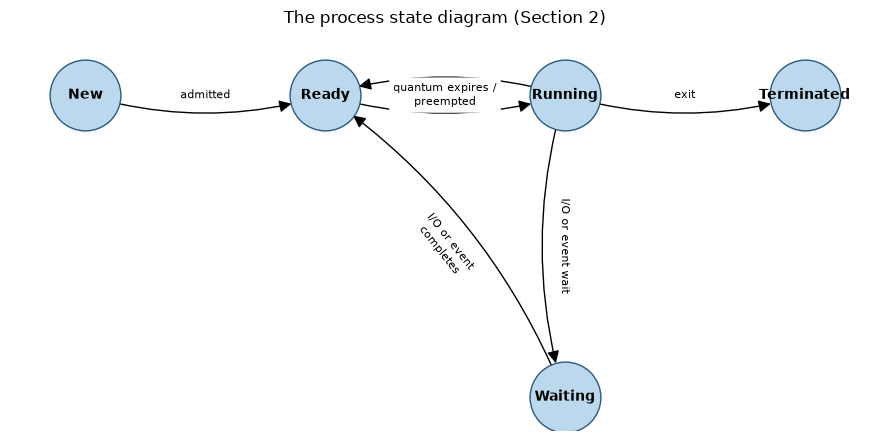

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
edges = [
    ("New", "Ready", "admitted"),
    ("Ready", "Running", "scheduler dispatch"),
    ("Running", "Ready", "quantum expires /\npreempted"),
    ("Running", "Waiting", "I/O or event wait"),
    ("Waiting", "Ready", "I/O or event\ncompletes"),
    ("Running", "Terminated", "exit"),
]
for u, v, label in edges:
    G.add_edge(u, v, label=label)

pos = {
    "New": (0, 1),
    "Ready": (1, 1),
    "Running": (2, 1),
    "Waiting": (2, 0),
    "Terminated": (3, 1),
}

fig, ax = plt.subplots(figsize=(9, 4.5))
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color="#bcd8ec", edgecolors="#2a5a82", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos, ax=ax, connectionstyle="arc3,rad=0.15", arrowsize=18,
    min_source_margin=25, min_target_margin=25,
)
edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title("The process state diagram (Section 2)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Implementation: CPU scheduling

**The everyday version of this problem:** a coffee shop with one barista and
a line of customers. Do you serve whoever arrived first (fair, but a slow
order can hold up ten fast ones behind it)? Whoever wants the least
espresso (fast on average, but the one huge catering order might never get
served)? A fixed slice of attention per customer, round and round (fair
turn-taking, but everyone waits a bit for everyone)? CPU **scheduling** is
this exact problem, with processes instead of customers and the CPU
instead of the barista.

### The workload

We'll run every algorithm below on the *same* five processes so the
comparison is apples-to-apples. `arrival` is when the process becomes
ready to run, `burst` is how much CPU time it needs in total, and
`priority` (lower = more urgent) is used only by the priority-based
schedulers.

In [3]:
processes = [
    {"pid": "P1", "arrival": 0, "burst": 8, "priority": 3},
    {"pid": "P2", "arrival": 1, "burst": 4, "priority": 1},
    {"pid": "P3", "arrival": 2, "burst": 9, "priority": 4},
    {"pid": "P4", "arrival": 3, "burst": 5, "priority": 2},
    {"pid": "P5", "arrival": 4, "burst": 2, "priority": 5},
]

for p in processes:
    print(p)

{'pid': 'P1', 'arrival': 0, 'burst': 8, 'priority': 3}
{'pid': 'P2', 'arrival': 1, 'burst': 4, 'priority': 1}
{'pid': 'P3', 'arrival': 2, 'burst': 9, 'priority': 4}
{'pid': 'P4', 'arrival': 3, 'burst': 5, 'priority': 2}
{'pid': 'P5', 'arrival': 4, 'burst': 2, 'priority': 5}


### Formal definitions

For a process $i$ with arrival time $A_i$, burst time $B_i$, and
completion time $C_i$ (when it finishes for good):

$$
\text{Turnaround time } T_i = C_i - A_i
\qquad\qquad
\text{Waiting time } W_i = T_i - B_i
$$

Turnaround time is "how long did this process take from the customer's
point of view, start to finish." Waiting time is turnaround time minus the
time actually spent computing — i.e. time spent sitting in the ready queue
doing nothing. We'll report the **average** of each across all 5 processes
for every algorithm, plus draw a **Gantt chart**: a timeline showing which
process holds the CPU during which interval.

In [4]:
import matplotlib.pyplot as plt

def summarize(schedule, procs):
    # schedule: list of (pid, start, end) CPU intervals, in the order they ran.
    # returns per-process (arrival, burst, completion, turnaround, waiting) plus averages.
    completion = {}
    for pid, start, end in schedule:
        completion[pid] = end  # last interval's end time = completion time
    arrival = {p["pid"]: p["arrival"] for p in procs}
    burst = {p["pid"]: p["burst"] for p in procs}

    rows = []
    for p in procs:
        pid = p["pid"]
        turnaround = completion[pid] - arrival[pid]
        waiting = turnaround - burst[pid]
        rows.append(dict(pid=pid, arrival=arrival[pid], burst=burst[pid],
                          completion=completion[pid], turnaround=turnaround, waiting=waiting))
    avg_turnaround = sum(r["turnaround"] for r in rows) / len(rows)
    avg_waiting = sum(r["waiting"] for r in rows) / len(rows)
    return rows, avg_turnaround, avg_waiting


def gantt_chart(ax, schedule, title):
    pids = sorted({pid for pid, _, _ in schedule})
    colors = plt.cm.Set2(range(len(pids)))
    color_of = dict(zip(pids, colors))
    for pid, start, end in schedule:
        ax.broken_barh([(start, end - start)], (0, 1), facecolors=color_of[pid], edgecolor="black")
        ax.text((start + end) / 2, 0.5, pid, ha="center", va="center", fontsize=9)
    ax.set_yticks([])
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.set_xlim(0, max(end for _, _, end in schedule) + 0.5)


def report(name, schedule, procs):
    rows, avg_tat, avg_wt = summarize(schedule, procs)
    print(f"--- {name} ---")
    for r in rows:
        print(f"  {r['pid']}: arrival={r['arrival']:2d} burst={r['burst']:2d} "
              f"completion={r['completion']:2d} turnaround={r['turnaround']:2d} waiting={r['waiting']:2d}")
    print(f"  avg turnaround = {avg_tat:.2f}, avg waiting = {avg_wt:.2f}")
    return avg_tat, avg_wt

### First-Come, First-Served (FCFS)

The simplest possible policy: run processes in arrival order, each to
completion, no interruptions.

--- FCFS ---
  P1: arrival= 0 burst= 8 completion= 8 turnaround= 8 waiting= 0
  P2: arrival= 1 burst= 4 completion=12 turnaround=11 waiting= 7
  P3: arrival= 2 burst= 9 completion=21 turnaround=19 waiting=10
  P4: arrival= 3 burst= 5 completion=26 turnaround=23 waiting=18
  P5: arrival= 4 burst= 2 completion=28 turnaround=24 waiting=22
  avg turnaround = 17.00, avg waiting = 11.40


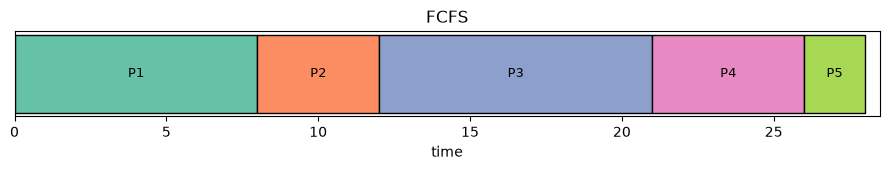

In [5]:
def fcfs(procs):
    order = sorted(procs, key=lambda p: (p["arrival"], p["pid"]))
    t = 0
    schedule = []
    for p in order:
        start = max(t, p["arrival"])   # CPU may sit idle if nothing has arrived yet
        end = start + p["burst"]
        schedule.append((p["pid"], start, end))
        t = end
    return schedule

sched_fcfs = fcfs(processes)
tat_fcfs, wt_fcfs = report("FCFS", sched_fcfs, processes)

fig, ax = plt.subplots(figsize=(9, 1.8))
gantt_chart(ax, sched_fcfs, "FCFS")
plt.tight_layout()
plt.show()

Notice **P3** (burst 9, the longest job) arrived early and ran early, and
every process behind it in the queue had to wait for all 9 of its units —
this is the classic FCFS weakness: the **convoy effect**, where one long
job holds up a line of short ones.

### Shortest Job First (SJF), non-preemptive

Instead of arrival order, always run whichever *ready* process has the
smallest remaining burst time next. This provably minimizes average
waiting time among non-preemptive policies *if* burst times are known in
advance — a big "if" we return to in Limitations & debates.

--- SJF (non-preemptive) ---
  P1: arrival= 0 burst= 8 completion= 8 turnaround= 8 waiting= 0
  P2: arrival= 1 burst= 4 completion=14 turnaround=13 waiting= 9
  P3: arrival= 2 burst= 9 completion=28 turnaround=26 waiting=17
  P4: arrival= 3 burst= 5 completion=19 turnaround=16 waiting=11
  P5: arrival= 4 burst= 2 completion=10 turnaround= 6 waiting= 4
  avg turnaround = 13.80, avg waiting = 8.20


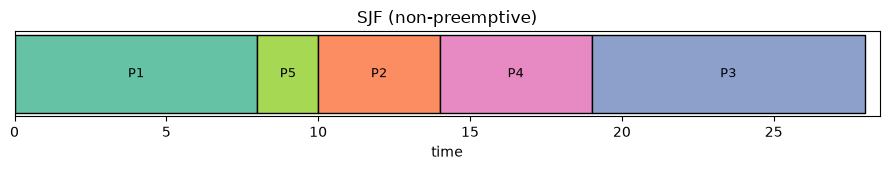

In [6]:
def sjf_nonpreemptive(procs):
    remaining = sorted(procs, key=lambda p: p["arrival"])
    t = 0
    schedule = []
    done = set()
    while len(done) < len(procs):
        ready = [p for p in remaining if p["arrival"] <= t and p["pid"] not in done]
        if not ready:
            t = min(p["arrival"] for p in remaining if p["pid"] not in done)
            continue
        p = min(ready, key=lambda p: (p["burst"], p["arrival"]))
        start = t
        end = start + p["burst"]
        schedule.append((p["pid"], start, end))
        t = end
        done.add(p["pid"])
    return schedule

sched_sjf = sjf_nonpreemptive(processes)
tat_sjf, wt_sjf = report("SJF (non-preemptive)", sched_sjf, processes)

fig, ax = plt.subplots(figsize=(9, 1.8))
gantt_chart(ax, sched_sjf, "SJF (non-preemptive)")
plt.tight_layout()
plt.show()

### Round Robin (RR)

Give every ready process a fixed **time quantum**; if it doesn't finish, it
goes to the back of the queue and waits its turn again. This is the
textbook fairness-first policy: no process waits more than
$(n-1) \times \text{quantum}$ for its next turn.

--- Round Robin (quantum=3) ---
  P1: arrival= 0 burst= 8 completion=25 turnaround=25 waiting=17
  P2: arrival= 1 burst= 4 completion=18 turnaround=17 waiting=13
  P3: arrival= 2 burst= 9 completion=28 turnaround=26 waiting=17
  P4: arrival= 3 burst= 5 completion=23 turnaround=20 waiting=15
  P5: arrival= 4 burst= 2 completion=17 turnaround=13 waiting=11
  avg turnaround = 20.20, avg waiting = 14.60


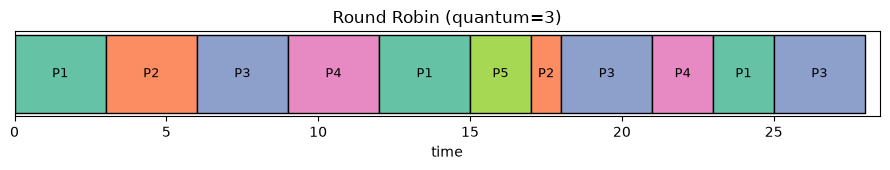

In [7]:
from collections import deque

def round_robin(procs, quantum):
    remaining = {p["pid"]: p["burst"] for p in procs}
    order = sorted(procs, key=lambda p: p["arrival"])
    idx, n = 0, len(order)
    t = 0
    q = deque()
    schedule = []

    def admit(now):
        nonlocal idx
        while idx < n and order[idx]["arrival"] <= now:
            q.append(order[idx]["pid"])
            idx += 1

    admit(t)
    if not q and idx < n:
        t = order[idx]["arrival"]
        admit(t)

    while q:
        pid = q.popleft()
        run = min(quantum, remaining[pid])
        start, end = t, t + run
        schedule.append((pid, start, end))
        t = end
        remaining[pid] -= run
        admit(t)                      # newcomers join the queue before the just-run process re-joins
        if remaining[pid] > 0:
            q.append(pid)
        if not q and idx < n:
            t = max(t, order[idx]["arrival"])
            admit(t)
    return schedule

sched_rr = round_robin(processes, quantum=3)
tat_rr, wt_rr = report("Round Robin (quantum=3)", sched_rr, processes)

fig, ax = plt.subplots(figsize=(9, 1.8))
gantt_chart(ax, sched_rr, "Round Robin (quantum=3)")
plt.tight_layout()
plt.show()

### Priority scheduling and a multilevel feedback queue (MLFQ)

**Priority scheduling** (non-preemptive here) always runs the ready process
with the best (lowest-numbered) priority. Its weakness is **starvation** —
a low-priority process can wait forever if higher-priority work keeps
arriving (real systems fix this with *aging*, gradually raising the
priority of processes that have waited a long time).

**MLFQ** is what most general-purpose schedulers historically approximated
before more modern fairness-based designs (Section 8): multiple queues at
different priority levels. A process starts in the top (Round Robin) queue;
if it uses its whole quantum without finishing, it's demoted to a lower
queue. Short, interactive jobs tend to finish (or block for I/O) within
their first quantum and stay fast; long CPU-bound jobs sink to the back.

--- Priority (non-preemptive) ---
  P1: arrival= 0 burst= 8 completion= 8 turnaround= 8 waiting= 0
  P2: arrival= 1 burst= 4 completion=12 turnaround=11 waiting= 7
  P3: arrival= 2 burst= 9 completion=26 turnaround=24 waiting=15
  P4: arrival= 3 burst= 5 completion=17 turnaround=14 waiting= 9
  P5: arrival= 4 burst= 2 completion=28 turnaround=24 waiting=22
  avg turnaround = 16.20, avg waiting = 10.60


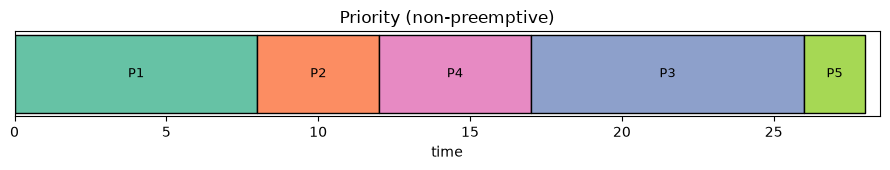

--- MLFQ (RR(3) -> FCFS) ---
  P1: arrival= 0 burst= 8 completion=19 turnaround=19 waiting=11
  P2: arrival= 1 burst= 4 completion=20 turnaround=19 waiting=15
  P3: arrival= 2 burst= 9 completion=26 turnaround=24 waiting=15
  P4: arrival= 3 burst= 5 completion=28 turnaround=25 waiting=20
  P5: arrival= 4 burst= 2 completion=14 turnaround=10 waiting= 8
  avg turnaround = 19.40, avg waiting = 13.80


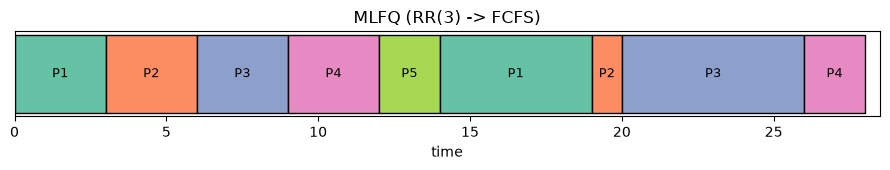

In [8]:
def priority_nonpreemptive(procs):
    remaining = sorted(procs, key=lambda p: p["arrival"])
    t = 0
    schedule = []
    done = set()
    while len(done) < len(procs):
        ready = [p for p in remaining if p["arrival"] <= t and p["pid"] not in done]
        if not ready:
            t = min(p["arrival"] for p in remaining if p["pid"] not in done)
            continue
        p = min(ready, key=lambda p: (p["priority"], p["arrival"]))  # lower number = higher priority
        start, end = t, t + p["burst"]
        schedule.append((p["pid"], start, end))
        t = end
        done.add(p["pid"])
    return schedule


def mlfq(procs, q0_quantum=3):
    # two levels: level 0 = Round Robin(q0_quantum), level 1 = FCFS run-to-completion.
    remaining = {p["pid"]: p["burst"] for p in procs}
    order = sorted(procs, key=lambda p: p["arrival"])
    idx, n = 0, len(order)
    t = 0
    level0, level1 = deque(), deque()
    schedule = []

    def admit(now):
        nonlocal idx
        while idx < n and order[idx]["arrival"] <= now:
            level0.append(order[idx]["pid"])
            idx += 1

    admit(t)
    while level0 or level1 or idx < n:
        if not level0 and not level1:
            t = order[idx]["arrival"]
            admit(t)
            continue
        if level0:
            pid = level0.popleft()
            run = min(q0_quantum, remaining[pid])
            start, end = t, t + run
            schedule.append((pid, start, end))
            t = end
            remaining[pid] -= run
            admit(t)
            if remaining[pid] > 0:
                level1.append(pid)          # used up its quantum -> demoted
        else:
            pid = level1.popleft()
            start, end = t, t + remaining[pid]
            schedule.append((pid, start, end))
            t = end
            remaining[pid] = 0
            admit(t)
    return schedule

sched_pri = priority_nonpreemptive(processes)
tat_pri, wt_pri = report("Priority (non-preemptive)", sched_pri, processes)
fig, ax = plt.subplots(figsize=(9, 1.8))
gantt_chart(ax, sched_pri, "Priority (non-preemptive)")
plt.tight_layout()
plt.show()

sched_mlfq = mlfq(processes, q0_quantum=3)
tat_mlfq, wt_mlfq = report("MLFQ (RR(3) -> FCFS)", sched_mlfq, processes)
fig, ax = plt.subplots(figsize=(9, 1.8))
gantt_chart(ax, sched_mlfq, "MLFQ (RR(3) -> FCFS)")
plt.tight_layout()
plt.show()

### Comparing all five on the same workload

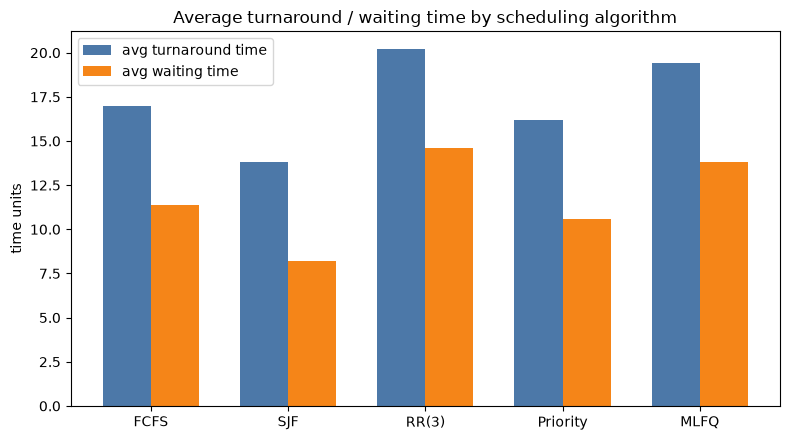

Algorithm    avg turnaround   avg waiting
FCFS                  17.00        11.40
SJF                   13.80         8.20
RR(3)                 20.20        14.60
Priority              16.20        10.60
MLFQ                  19.40        13.80


In [9]:
names = ["FCFS", "SJF", "RR(3)", "Priority", "MLFQ"]
avg_tats = [tat_fcfs, tat_sjf, tat_rr, tat_pri, tat_mlfq]
avg_wts = [wt_fcfs, wt_sjf, wt_rr, wt_pri, wt_mlfq]

x = range(len(names))
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.35
ax.bar([i - width/2 for i in x], avg_tats, width, label="avg turnaround time", color="#4c78a8")
ax.bar([i + width/2 for i in x], avg_wts, width, label="avg waiting time", color="#f58518")
ax.set_xticks(list(x))
ax.set_xticklabels(names)
ax.set_ylabel("time units")
ax.set_title("Average turnaround / waiting time by scheduling algorithm")
ax.legend()
plt.tight_layout()
plt.show()

print("Algorithm    avg turnaround   avg waiting")
for name, tat, wt in zip(names, avg_tats, avg_wts):
    print(f"{name:<12} {tat:>14.2f}   {wt:>10.2f}")

**Reading the real numbers:** on this exact workload, SJF gets the lowest
average waiting time of the non-preemptive policies — expected, since SJF
is provably optimal for average waiting time *when burst times are known
up front*. FCFS is worst on average waiting because P3's long 9-unit burst
sits at the front of the queue holding everyone up (the convoy effect made
concrete). Round Robin and MLFQ trade some average-case waiting for
**fairness**: no single process is ever stuck behind an arbitrarily long
one for an arbitrarily long time, which matters far more for interactive
workloads (a UI thread) than for batch workloads (a video render).

## 5. Implementation: memory management & virtual machine memory (paging)

**The everyday version of this problem:** your desk (physical RAM) is small,
but your filing cabinet warehouse (disk) is huge. You can't fit every
project on your desk, so you keep the pages you're actively using on the
desk and the rest in the warehouse, pulling a page in when you need it and
putting one back when the desk is full. **Virtual memory** is the OS doing
exactly this for every process automatically, and giving each process the
illusion that it has the entire address space to itself.

### Paging, formally

The OS divides a process's **virtual address space** into fixed-size
**pages** (commonly 4 KiB) and physical RAM into same-size **frames**. A
**page table** maps virtual page numbers to physical frame numbers. A
virtual address is split into:

$$
\text{virtual address} = \underbrace{p}_{\text{page number}} \; \| \; \underbrace{d}_{\text{offset within page}}
$$

To read virtual address $(p, d)$: look up frame number $f = \text{PageTable}[p]$,
then the physical address is $(f, d)$ — same offset, translated frame. If
$\text{PageTable}[p]$ says "not currently in RAM," that's a **page fault**:
the OS must fetch the page from disk into some free frame (or evict another
page to make room) before the access can continue. Because a page fault
means a disk access — orders of magnitude slower than RAM — **minimizing
page faults is the entire game**, and it comes down to one question: when
RAM is full and a new page must come in, *which resident page do we evict?*

### Three replacement policies

- **FIFO** — evict whichever resident page has been in memory the longest,
  regardless of how recently it was used.
- **LRU (Least Recently Used)** — evict the page that hasn't been
  *referenced* for the longest time; approximates "pages used recently
  will likely be used again soon" (temporal locality).
- **Optimal (Bélády's algorithm)** — evict the page that won't be needed
  again for the longest time *in the future*. Requires knowing the future
  reference sequence, so it's not implementable in a real OS — it exists
  purely as a theoretical lower bound to measure other algorithms against.

In [10]:
def fifo_faults(ref, n_frames):
    from collections import deque
    memory, in_memory = deque(), set()
    faults = 0
    for page in ref:
        if page not in in_memory:
            faults += 1
            if len(memory) >= n_frames:
                evicted = memory.popleft()
                in_memory.remove(evicted)
            memory.append(page)
            in_memory.add(page)
    return faults


def lru_faults(ref, n_frames):
    memory = []  # ordered oldest-used (front) -> most-recently-used (back)
    faults = 0
    for page in ref:
        if page in memory:
            memory.remove(page)      # re-insert at the "recently used" end
            memory.append(page)
        else:
            faults += 1
            if len(memory) >= n_frames:
                memory.pop(0)         # evict least-recently-used
            memory.append(page)
    return faults


def optimal_faults(ref, n_frames):
    memory = []
    faults = 0
    for i, page in enumerate(ref):
        if page in memory:
            continue
        faults += 1
        if len(memory) >= n_frames:
            future = ref[i + 1:]
            # evict whichever resident page is used furthest in the future (or never again)
            def next_use(m):
                return future.index(m) if m in future else float("inf")
            evict = max(memory, key=next_use)
            memory.remove(evict)
        memory.append(page)
    return faults

### Running all three on a real reference string

We'll use a reference string that's famous for a reason you're about to
see: `1,2,3,4,1,2,5,1,2,3,4,5,1,2,3` (from Bélády, Nelson & Shedler 1969).
We compute page faults for frame counts 1 through 6, for all three
algorithms.

In [11]:
reference_string = [1, 2, 3, 4, 1, 2, 5, 1, 2, 3, 4, 5, 1, 2, 3]
frame_counts = list(range(1, 7))

fifo_results = [fifo_faults(reference_string, f) for f in frame_counts]
lru_results = [lru_faults(reference_string, f) for f in frame_counts]
opt_results = [optimal_faults(reference_string, f) for f in frame_counts]

print(f"reference string: {reference_string}  (length {len(reference_string)})\n")
print(f"{'frames':>6}  {'FIFO':>6}  {'LRU':>6}  {'OPT':>6}")
for f, ff, lf, of in zip(frame_counts, fifo_results, lru_results, opt_results):
    print(f"{f:>6}  {ff:>6}  {lf:>6}  {of:>6}")

reference string: [1, 2, 3, 4, 1, 2, 5, 1, 2, 3, 4, 5, 1, 2, 3]  (length 15)

frames    FIFO     LRU     OPT
     1      15      15      15
     2      15      15      12
     3      12      13       9
     4      13      11       7
     5       5       5       5
     6       5       5       5


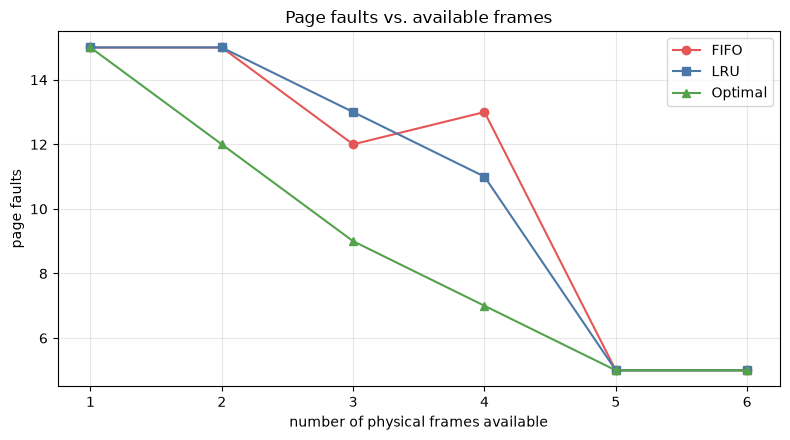

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(frame_counts, fifo_results, marker="o", label="FIFO", color="#e45756")
ax.plot(frame_counts, lru_results, marker="s", label="LRU", color="#4c78a8")
ax.plot(frame_counts, opt_results, marker="^", label="Optimal", color="#54a24b")
ax.set_xlabel("number of physical frames available")
ax.set_ylabel("page faults")
ax.set_title("Page faults vs. available frames")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Bélády's anomaly, reproduced with real numbers:** look at FIFO going from
3 frames to 4 frames in the table above — the fault count goes **up**
(from 12 to 13 faults), even though we gave the algorithm *more*
memory. That's Bélády's anomaly: for FIFO specifically, more frames can
mean *more* faults, because FIFO's eviction choice depends only on
insertion order, which shifts unpredictably as the frame count changes.

Compare that to LRU and Optimal, which are both non-increasing across the
whole table — giving them more memory never hurts. This isn't a
coincidence: LRU and Optimal are both **stack algorithms** (the set of
pages resident with $k$ frames is always a subset of the set resident with
$k+1$ frames), which provably rules out the anomaly. FIFO is not a stack
algorithm, which is exactly why it's the one that misbehaves.

## 6. Implementation: synchronization

**The everyday version of this problem:** two roommates share one bank
account. Both check the balance ($100), both decide to withdraw $80, and
both submit the withdrawal at almost the same instant. If the bank doesn't
coordinate those two operations carefully, the account can end up at $20
when it should have been rejected outright (only $100 existed, $160 was
withdrawn) — or worse, silently overwritten so it looks like only one
withdrawal happened at all. That's a **race condition**: the outcome
depends on the precise, unpredictable timing of two things happening "at
the same time."

### A real race condition

The classic version of this in code is `counter += 1` run concurrently by
multiple threads. It *looks* like one atomic step, but it's really three:
**read** the current value, **add** 1, **write** it back. If two threads
interleave those three steps, an update can get lost. Below, we force the
interleaving to be visible on every run by explicitly yielding
(`time.sleep(0)`) between the read and the write — in real programs the
same hazard exists but shows up *probabilistically*, only under certain
scheduling timing, which is exactly what makes race conditions so
notoriously hard to debug: they can pass every test and still fail in
production.

In [13]:
import threading
import time

shared_counter = 0

def increment_unsafe(n_iterations):
    global shared_counter
    for _ in range(n_iterations):
        temp = shared_counter   # READ
        time.sleep(0)           # yield control to another thread here (widens the race window)
        shared_counter = temp + 1  # WRITE (based on a possibly-stale READ)

N_ITERATIONS = 2000
N_THREADS = 4
threads = [threading.Thread(target=increment_unsafe, args=(N_ITERATIONS,)) for _ in range(N_THREADS)]
for t in threads:
    t.start()
for t in threads:
    t.join()

expected = N_ITERATIONS * N_THREADS
print(f"expected final count: {expected}")
print(f"actual final count:   {shared_counter}")
print(f"lost updates:         {expected - shared_counter}")

expected final count: 8000
actual final count:   2360
lost updates:         5640


That's a real, measured discrepancy from an actual run in this notebook —
not a hypothetical. Every "lost update" above is a case where two threads
both read the same value, both incremented it, and one thread's write
silently clobbered the other's.

### The fix: mutual exclusion with a lock

A **mutex** (mutual exclusion lock) guarantees that only one thread can be
inside the "critical section" — the read-modify-write — at a time. Any
correct solution to the mutual exclusion problem must satisfy three
formal requirements (Dijkstra, 1965):

1. **Mutual exclusion** — at most one process/thread is in its critical
   section at any time.
2. **Progress** — if no one is in the critical section, one of the
   processes that wants in must be able to get in, in finite time (no
   process outside the critical section can block the decision forever).
3. **Bounded waiting** — there's a limit on how many times other
   processes can enter the critical section after a process has requested
   entry and before that request is granted (no permanent starvation).

Python's `threading.Lock` gives us exactly this via `acquire()`/`release()`
(or the `with lock:` context manager, which is exactly `acquire()` then a
guaranteed `release()`). A **semaphore** generalizes a lock to allow up to
$N$ threads into a region at once, via two atomic operations: $\text{P}$
(a.k.a. `acquire`/`wait`, decrements the count, blocking if it would go
below 0) and $\text{V}$ (a.k.a. `release`/`signal`, increments the count).
A lock is exactly a semaphore initialized to 1.

In [14]:
safe_counter = 0
lock = threading.Lock()

def increment_safe(n_iterations):
    global safe_counter
    for _ in range(n_iterations):
        with lock:                    # only one thread executes this block at a time
            temp = safe_counter
            time.sleep(0)
            safe_counter = temp + 1

threads = [threading.Thread(target=increment_safe, args=(N_ITERATIONS,)) for _ in range(N_THREADS)]
for t in threads:
    t.start()
for t in threads:
    t.join()

print(f"expected final count: {expected}")
print(f"actual final count:   {safe_counter}")
print(f"lost updates:         {expected - safe_counter}")

expected final count: 8000
actual final count:   8000
lost updates:         0


With the lock, every single update survives — zero lost updates, every
time this cell runs. That's mutual exclusion doing its job.

### Deadlock

Locks solve races, but introduce a new failure mode. **Deadlock** is when
two or more threads are each waiting for a resource the other holds, so
*none* of them can ever proceed. Coffman, Elphick & Shoshani (1971) showed
deadlock requires all four of these to hold simultaneously — this is worth
memorizing, because every deadlock-avoidance technique works by denying
one of these four:

1. **Mutual exclusion** — resources can't be shared (only one thread can
   hold a given lock at a time).
2. **Hold and wait** — a thread holding one resource can request another
   without releasing what it already has.
3. **No preemption** — a resource can only be released voluntarily by the
   thread holding it, never forcibly taken away.
4. **Circular wait** — there's a cycle of threads, each waiting for a
   resource held by the next one in the cycle.

Let's trigger a real one: two threads, two locks, acquired in **opposite
order**. We use a `Barrier` to force both threads to have already grabbed
their first lock before either tries for the second — that's what
guarantees this reliably deadlocks instead of only "usually, depending on
timing".

In [15]:
lock_a = threading.Lock()
lock_b = threading.Lock()
start_barrier = threading.Barrier(2)  # forces both threads to reach this line before either continues
done_barrier = threading.Barrier(2)   # forces both threads to finish their attempt before either releases
outcome = {}

def thread_1():
    lock_a.acquire()
    start_barrier.wait()                   # both threads now hold their first lock
    got_b = lock_b.acquire(timeout=1.5)    # tries for the other thread's lock -> blocks
    if got_b:
        lock_b.release()
    outcome["thread_1_got_lock_b"] = got_b
    done_barrier.wait()                    # don't free lock_a until thread_2's attempt has also resolved
    lock_a.release()

def thread_2():
    lock_b.acquire()
    start_barrier.wait()
    got_a = lock_a.acquire(timeout=1.5)    # tries for the other thread's lock -> blocks
    if got_a:
        lock_a.release()
    outcome["thread_2_got_lock_a"] = got_a
    done_barrier.wait()                    # don't free lock_b until thread_1's attempt has also resolved
    lock_b.release()

t1 = threading.Thread(target=thread_1)
t2 = threading.Thread(target=thread_2)
start = time.perf_counter()
t1.start(); t2.start()
t1.join(); t2.join()
elapsed = time.perf_counter() - start

print(f"outcome: {outcome}")
print(f"elapsed: {elapsed:.2f}s (both requests timed out waiting on the *other* thread's lock -> real deadlock)")

outcome: {'thread_1_got_lock_b': False, 'thread_2_got_lock_a': False}
elapsed: 1.52s (both requests timed out waiting on the *other* thread's lock -> real deadlock)


Both `False` — neither thread ever got the second lock it needed, and the
elapsed time matches the 1.5s timeout we set (without a timeout, both
threads would hang forever; we added the timeout purely so this cell
finishes and reports a result instead of freezing the notebook). This is
circular wait (condition 4) in action: thread 1 holds lock A and wants
lock B; thread 2 holds lock B and wants lock A.

### Resolution #1: lock ordering

The simplest fix in practice: **always acquire locks in a fixed, agreed
order**, everywhere in the codebase. This breaks condition 4 (circular
wait) by construction — if everyone acquires lock A before lock B, there's
no cycle possible.

In [16]:
outcome_fixed = {}

def thread_1_fixed():
    with lock_a:              # always A, then B
        with lock_b:
            outcome_fixed["thread_1"] = "acquired both locks"

def thread_2_fixed():
    with lock_a:              # thread 2 also does A, then B -- not B, then A
        with lock_b:
            outcome_fixed["thread_2"] = "acquired both locks"

t1 = threading.Thread(target=thread_1_fixed)
t2 = threading.Thread(target=thread_2_fixed)
start = time.perf_counter()
t1.start(); t2.start()
t1.join(timeout=3); t2.join(timeout=3)
elapsed = time.perf_counter() - start

print(f"outcome: {outcome_fixed}")
print(f"elapsed: {elapsed:.3f}s (both threads finished -- no deadlock, because there's no cycle to wait on)")

outcome: {'thread_1': 'acquired both locks', 'thread_2': 'acquired both locks'}
elapsed: 0.096s (both threads finished -- no deadlock, because there's no cycle to wait on)


### Resolution #2: the Banker's algorithm (deadlock avoidance)

Lock ordering is a discipline you enforce by convention. The **Banker's
algorithm** (Dijkstra) instead avoids deadlock *dynamically*: every process
declares its **maximum possible claim** on each resource type up front,
and the OS only grants a request if doing so leaves the system in a
**safe state** — a state from which *some* order exists to let every
process finish, one at a time, using only currently-available resources
plus what finished processes give back.

Formally, with $n$ processes and $m$ resource types:

- $\text{Available}[j]$ — instances of resource $j$ currently free.
- $\text{Allocation}[i][j]$ — instances of resource $j$ currently held by process $i$.
- $\text{Max}[i][j]$ — the most instances of resource $j$ process $i$ will ever request.
- $\text{Need}[i][j] = \text{Max}[i][j] - \text{Allocation}[i][j]$ — how much more process $i$ might still ask for.

**Safety algorithm:** repeatedly find a process $i$ not yet finished whose
$\text{Need}[i] \le \text{Available}$ (component-wise); pretend it runs to
completion and gives its allocation back
($\text{Available} \mathrel{+}= \text{Allocation}[i]$); repeat. If every
process gets finished this way, the state is safe and a safe sequence
exists; if you get stuck with remaining processes whose need can never be
met, the state is unsafe.

In [17]:
def is_safe_state(available, allocation, maximum):
    n_processes, n_resources = len(allocation), len(available)
    need = [[maximum[i][j] - allocation[i][j] for j in range(n_resources)] for i in range(n_processes)]
    work = list(available)
    finished = [False] * n_processes
    safe_sequence = []

    progressed = True
    while progressed:
        progressed = False
        for i in range(n_processes):
            if not finished[i] and all(need[i][j] <= work[j] for j in range(n_resources)):
                work = [work[j] + allocation[i][j] for j in range(n_resources)]
                finished[i] = True
                safe_sequence.append(i)
                progressed = True

    return all(finished), safe_sequence

# The classic Silberschatz/Galvin/Gagne textbook example: 5 processes, 3 resource types (A, B, C).
available = [3, 3, 2]
allocation = [
    [0, 1, 0],   # P0
    [2, 0, 0],   # P1
    [3, 0, 2],   # P2
    [2, 1, 1],   # P3
    [0, 0, 2],   # P4
]
maximum = [
    [7, 5, 3],   # P0
    [3, 2, 2],   # P1
    [9, 0, 2],   # P2
    [2, 2, 2],   # P3
    [4, 3, 3],   # P4
]

safe, sequence = is_safe_state(available, allocation, maximum)
print(f"is this state safe? {safe}")
print(f"safe sequence: {[f'P{i}' for i in sequence]}")

is this state safe? True
safe sequence: ['P1', 'P3', 'P4', 'P0', 'P2']


The algorithm found a real safe sequence — every process can be guaranteed
to finish without deadlock if the OS admits requests in this order (or any
order it discovers is safe). A real resource manager runs this check
*before granting each individual request* — if granting a request would
move the system into an unsafe state, the request is postponed (the
requesting process just waits) even though enough resources exist right
now, because "enough right now" doesn't guarantee "enough for everyone
eventually."

> **Takeaway:** races come from unsynchronized read-modify-write access to
> shared state, and locks fix them at the cost of introducing deadlock
> risk; deadlock needs all four Coffman conditions, so breaking any one —
> via a fixed lock order or via the Banker's algorithm's safety check —
> prevents it.

## 7. Implementation: file systems basics

**The everyday version of this problem:** a library's card catalog doesn't
store books — it stores, for each book, a pointer to where on the shelves
that book actually lives. A **file system** does the same for a disk: it
tracks, for every file, which physical disk blocks hold its data, without
requiring the data itself to be contiguous.

### Inodes and allocation strategies

An **inode** ("index node") is the per-file record most Unix-like file
systems use: file metadata (size, permissions, timestamps, owner) plus
either the addresses of the data blocks themselves or pointers to blocks
that list those addresses (indirect blocks, for large files). Crucially,
the *filename* isn't stored in the inode at all — a directory is just a
list mapping names to inode numbers, which is exactly why hard links (two
names, one inode) are possible.

How a file's blocks are actually laid out on disk is the **allocation
strategy**:

| Strategy | Idea | Pro | Con |
|---|---|---|---|
| **Contiguous** | File occupies one unbroken run of blocks. | Fast sequential *and* random access (one seek). | External fragmentation; hard to grow a file in place. |
| **Linked** | Each block holds a pointer to the next block of the same file. | No external fragmentation; easy to grow. | Random access is slow (must walk the chain); a lost pointer corrupts the rest of the file. |
| **Indexed** | An index block lists every data block's address. | Fast random access, no external fragmentation. | The index block itself is overhead; very large files need indirect/multi-level index blocks. |

Real file systems (ext4, NTFS, APFS) use variants of indexed allocation,
often with **extents** (a start block + a length, so a whole contiguous
run is described in one entry instead of one entry per block) as a
practical middle ground between indexed and contiguous.

### A small simulated allocator

We'll simulate **indexed allocation** over a tiny 24-block disk: a
**free-space bitmap** (1 bit per block, 1 = in use) and an **inode table**
mapping filenames to their list of allocated block numbers.

In [18]:
class TinyFileSystem:
    def __init__(self, n_blocks):
        self.n_blocks = n_blocks
        self.free = [True] * n_blocks   # bitmap: True = free
        self.inodes = {}                # filename -> list of block numbers (the "index block")

    def create_file(self, name, size_in_blocks):
        free_blocks = [b for b in range(self.n_blocks) if self.free[b]]
        if len(free_blocks) < size_in_blocks:
            raise OSError(f"not enough free space for '{name}' ({size_in_blocks} blocks needed, "
                           f"{len(free_blocks)} free)")
        allocated = free_blocks[:size_in_blocks]   # indexed allocation: blocks need not be contiguous
        for b in allocated:
            self.free[b] = False
        self.inodes[name] = allocated
        return allocated

    def delete_file(self, name):
        for b in self.inodes.pop(name):
            self.free[b] = True

    def bitmap_str(self):
        return "".join("#" if not f else "." for f in self.free)

    def report(self):
        used = self.n_blocks - sum(self.free)
        print(f"disk: [{self.bitmap_str()}]  ({used}/{self.n_blocks} blocks used)")
        for name, blocks in self.inodes.items():
            contiguous = blocks == list(range(blocks[0], blocks[0] + len(blocks)))
            print(f"  inode '{name}': blocks={blocks}  contiguous={contiguous}")


fs = TinyFileSystem(n_blocks=24)
fs.create_file("notes.txt", 3)
fs.create_file("photo.jpg", 6)
fs.create_file("video.mp4", 8)
print("after creating 3 files:")
fs.report()

after creating 3 files:
disk: [#################.......]  (17/24 blocks used)
  inode 'notes.txt': blocks=[0, 1, 2]  contiguous=True
  inode 'photo.jpg': blocks=[3, 4, 5, 6, 7, 8]  contiguous=True
  inode 'video.mp4': blocks=[9, 10, 11, 12, 13, 14, 15, 16]  contiguous=True


Now delete the middle file and create two smaller ones — this is exactly
how real disks fragment over time, and it's the concrete reason **indexed**
(non-contiguous) allocation exists: `clip1.mp4` below gets scattered across
whatever holes are left, and it still works, because the inode simply
lists wherever its blocks ended up.

In [19]:
fs.delete_file("photo.jpg")
fs.create_file("clip1.mp4", 4)
fs.create_file("clip2.mp4", 2)
print("after deleting 'photo.jpg' and creating two more files:")
fs.report()

after deleting 'photo.jpg' and creating two more files:
disk: [#################.......]  (17/24 blocks used)
  inode 'notes.txt': blocks=[0, 1, 2]  contiguous=True
  inode 'video.mp4': blocks=[9, 10, 11, 12, 13, 14, 15, 16]  contiguous=True
  inode 'clip1.mp4': blocks=[3, 4, 5, 6]  contiguous=True
  inode 'clip2.mp4': blocks=[7, 8]  contiguous=True


`clip1.mp4`'s blocks are exactly where `photo.jpg`'s used to be — reused
immediately, no contiguity required. A contiguous-allocation file system
would have had to find one *unbroken* run of 4 free blocks, which gets
harder to guarantee the longer a disk has been in use; that's external
fragmentation, and it's the whole reason indexed/extent-based allocation
won out in practice.

## 8. Use cases: where this shows up in real systems

- **Scheduling.** Linux's default scheduler since 2007, the **Completely
  Fair Scheduler (CFS)**, is conceptually descended from the MLFQ/fairness
  ideas in Section 4, but tracks a *virtual runtime* per task in a
  red-black tree and always picks the task with the least accumulated
  runtime — a continuous generalization of "take turns" rather than
  discrete priority levels. Windows uses a multilevel, priority-based,
  preemptive scheduler with dynamic priority boosts for interactive
  threads — the "boost a thread that just woke up from I/O" behavior is a
  direct cousin of MLFQ's "short jobs stay near the front."
- **Virtual memory.** Every modern OS (Linux, Windows, macOS) gives every
  process its own virtual address space backed by paging, exactly as in
  Section 5 — this is *why* one process crashing doesn't corrupt another
  process's memory, and it's what makes memory overcommit in cloud VMs and
  containers (e.g. Kubernetes memory limits) possible: physical RAM is
  shared and oversubscribed, with paging (or, more precisely for
  containers, OOM-killing) as the pressure valve.
- **Synchronization.** Database systems use lock managers built on exactly
  the mutual-exclusion and deadlock machinery in Section 6 — a `SELECT ...
  FOR UPDATE` in Postgres takes a row lock the same way our `threading.Lock`
  does, and Postgres's deadlock detector periodically checks the
  wait-for graph for cycles (condition 4) and aborts one transaction to
  break it, which is deadlock *detection and recovery* rather than the
  *avoidance* techniques we implemented — a real tradeoff covered in
  Limitations & debates.
- **File systems.** ext4 uses **extents** (contiguous-run descriptors) on
  top of an inode structure very close to Section 7's; NTFS's Master File
  Table plays the same inode-table role. Both exist specifically to avoid
  the external-fragmentation problem our `TinyFileSystem` demo showed.

## 9. Limitations & debates

- **SJF and priority scheduling assume you know the future.** SJF needs
  each process's *burst time* before it runs it — but a general-purpose OS
  can't know how long an arbitrary program will run. Real systems only
  *estimate* future bursts (commonly an exponentially-weighted average of
  a process's past bursts) — so real "SJF-like" scheduling is
  approximate, not the clean optimal result we computed on a workload
  where the burst times were given to us up front.
- **No production general-purpose OS actually runs plain FCFS, SJF, RR, or
  classic MLFQ today.** They're the right pedagogical building blocks
  (and RR/MLFQ ideas genuinely live on inside CFS and the Windows
  scheduler, per Section 8), but real schedulers also have to handle
  multi-core load balancing, NUMA memory locality, per-core cache
  affinity, and power/thermal constraints that none of the algorithms
  here model at all.
- **True LRU is expensive to implement in real hardware.** Exact LRU
  needs a way to know the precise recency of every page's last access,
  which in practice would mean a timestamp or counter update on *every*
  memory reference — untenable at RAM speeds. Real OSes (Linux included)
  use an approximation called the **clock (second-chance) algorithm**,
  which uses a single hardware-maintained "referenced" bit per page and
  gets most of LRU's benefit far more cheaply. The pure LRU results in
  Section 5 are a useful reference point, not what's actually running on
  your machine right now.
- **The Optimal page-replacement algorithm is not implementable at all** —
  it requires knowing the future reference sequence, which no real system
  has. We used it purely as a lower-bound benchmark to see how close
  FIFO/LRU come to the best possible outcome, which is standard practice
  in the literature but worth stating plainly: it's a ruler, not a
  candidate algorithm.
- **Bélády's anomaly is specific to FIFO**, not a general property of page
  replacement — our own LRU/Optimal results were monotonic. It's cited
  constantly (including here) because it's such a clean counterexample to
  the intuitive "more memory can never hurt" assumption, but it shouldn't
  be over-generalized into "all replacement algorithms can behave this
  way."
- **The Banker's algorithm is rarely used in general-purpose OSes.** It
  requires every process to declare its maximum possible resource claim
  *before running* — real programs almost never know or state this
  up front, and overly conservative claims waste resources by making the
  safety check unnecessarily strict. In practice, most systems either
  don't try to avoid deadlock at all (accept the (small) risk, and use
  detection + recovery — kill/rollback a transaction, restart a
  process — when it happens), or sidestep it structurally with a fixed
  lock ordering, as we did with the simpler fix in Section 6. Banker's-style
  avoidance mainly shows up in embedded/real-time systems with a small,
  fixed, well-known set of resources.
- **This tutorial's `threading` demos show OS-level scheduling concepts,
  not multi-core parallelism.** As noted in Section 2, CPython's GIL means
  only one thread executes Python bytecode at a time regardless of core
  count. The race condition, lock, and deadlock demos are all genuine and
  their numbers are real, because those hazards come from *interleaving*
  (which the GIL still allows) rather than true simultaneity — but if you
  wanted actual multi-core speedup for CPU-bound Python work, you'd reach
  for `multiprocessing` (separate processes, separate GILs) instead.
- **Our `TinyFileSystem` is a teaching toy, not a real file system.** Real
  inodes handle sparse files, multi-level indirect blocks for files larger
  than a single index block can address, journaling for crash consistency,
  and access-control metadata — none of which we implemented.

## References

- Silberschatz, Galvin & Gagne, *Operating System Concepts*, 10th ed.,
  Wiley — the source for the five-state process model, the Banker's
  algorithm worked example used verbatim in Section 6, and the allocation
  strategy comparisons in Section 7.
- Tanenbaum & Bos, *Modern Operating Systems*, 4th ed., Pearson.
- Bélády, Nelson & Shedler (1969), *An Anomaly in Space-Time
  Characteristics of Certain Programs Running in a Paging Machine*, CACM
  — the original Bélády's anomaly paper; the reference string in Section 5
  reproduces this result.
- Dijkstra (1965), *Cooperating Sequential Processes* — the origin of the
  mutual-exclusion requirements and the semaphore, used in Section 6.
- Coffman, Elphick & Shoshani (1971), *System Deadlocks*, ACM Computing
  Surveys — the four necessary conditions for deadlock used in Section 6.
- CPython docs, [`threading` — Thread-based
  parallelism](https://docs.python.org/3/library/threading.html) and the
  [Global Interpreter
  Lock](https://docs.python.org/3/glossary.html#term-global-interpreter-lock).
- Linux kernel documentation, [Completely Fair
  Scheduler](https://docs.kernel.org/scheduler/sched-design-CFS.html).